# 01 — Exploração dos dados

## AI Quality Inspector

Nesta etapa será criada e analisada a base inicial de produtos utilizada no treinamento do modelo de Machine Learning.

### Objetivos

- conhecer a estrutura dos dados;
- identificar problemas de qualidade;
- analisar as variáveis disponíveis;
- preparar os dados para as próximas etapas do projeto.

## Execução e escopo

Esta análise utiliza 1.000 produtos sintéticos e compara classificadores antes de
exportar a Regressão Logística balanceada. Os resultados descrevem a simulação;
não representam validação com dados reais.

Instale `ml/requirements.txt`, selecione o kernel desse ambiente e execute todas
as células em ordem, com um kernel reiniciado. A semente `RANDOM_STATE = 42`
permite reproduzir os resultados no mesmo ambiente. Inicie o notebook na raiz
do repositório ou em uma de suas subpastas.


In [85]:
from IPython.display import display

import pandas as pd
import numpy as np

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

quantidade_produtos = 1000

dados = {
    "id_produto": range(1, quantidade_produtos + 1),

    "categoria": np.random.choice(
        ["Medicamento", "Cosmetico", "Higiene", "Suplemento"],
        quantidade_produtos
    ),

    "preco": np.round(
        np.random.uniform(5, 300, quantidade_produtos),
        2
    ),

    "quantidade": np.random.randint(
        1,
        200,
        quantidade_produtos
    ),

    "fornecedor": np.random.choice(
        ["Fornecedor A", "Fornecedor B", "Fornecedor C", "Fornecedor D"],
        quantidade_produtos
    ),

    "dias_para_vencer": np.random.randint(
        -30,
        730,
        quantidade_produtos
    ),

    "temperatura_armazenamento": np.round(
        np.random.uniform(2, 35, quantidade_produtos),
        1
    ),

    "historico_problemas": np.random.randint(
        0,
        6,
        quantidade_produtos
    ),
}

df = pd.DataFrame(dados)

print("Formato do dataset:", df.shape)
print("\nPrimeiros registros:")
print(df.head())

print("\nInformações gerais do DataFrame:")
df.info()

print("\nValores ausentes por coluna:")
print(df.isna().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nResumo estatístico das variáveis numéricas:")
print(df.describe().round(2))

print("\nDistribuição por categoria:")
print(df["categoria"].value_counts())

Formato do dataset: (1000, 8)

Primeiros registros:
   id_produto    categoria   preco  quantidade    fornecedor  \
0           1      Higiene  210.96          48  Fornecedor D   
1           2   Suplemento  163.15         194  Fornecedor B   
2           3  Medicamento   96.31         198  Fornecedor B   
3           4      Higiene  245.07         156  Fornecedor B   
4           5      Higiene  207.00         117  Fornecedor B   

   dias_para_vencer  temperatura_armazenamento  historico_problemas  
0               204                        8.0                    5  
1               -18                       26.5                    0  
2                70                       30.0                    1  
3               505                       20.0                    3  
4               492                       34.4                    3  

Informações gerais do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column    

## Criação da variável alvo

Como o projeto utiliza uma base sintética, será criada uma variável alvo
`precisa_revisao`.

Ela representa produtos que devem passar por uma revisão adicional de qualidade.

A probabilidade de revisão será influenciada por fatores como:

- proximidade ou ultrapassagem da validade;
- temperatura de armazenamento;
- histórico de problemas do produto.

Uma componente aleatória será mantida para evitar que a classificação seja
determinada por uma regra fixa.

In [86]:
probabilidade_risco = np.full(len(df), 0.05)

probabilidade_risco += np.where(
    df["dias_para_vencer"] < 30,
    0.35,
    0
)

probabilidade_risco += np.where(
    df["temperatura_armazenamento"] > 30,
    0.20,
    0
)

probabilidade_risco += np.where(
    df["historico_problemas"] >= 3,
    0.25,
    0
)

probabilidade_risco = np.clip(
    probabilidade_risco,
    0,
    0.95
)

df["precisa_revisao"] = np.random.binomial(
    1,
    probabilidade_risco
)

In [87]:
df[
    [
        "dias_para_vencer",
        "temperatura_armazenamento",
        "historico_problemas",
        "precisa_revisao",
    ]
].head(10)

,dias_para_vencer,temperatura_armazenamento,historico_problemas,precisa_revisao
0,204,8.0,5,0
1,-18,26.5,0,1
2,70,30.0,1,0
3,505,20.0,3,1
4,492,34.4,3,0
5,421,16.9,4,0
6,400,18.9,2,0
7,575,34.6,2,0
8,682,9.6,2,0
9,502,33.1,3,0


In [88]:
df["precisa_revisao"].value_counts()

precisa_revisao
0    781
1    219
Name: count, dtype: int64

In [89]:
df["precisa_revisao"].value_counts(normalize=True)

precisa_revisao
0    0.781
1    0.219
Name: proportion, dtype: float64

## Preparação para o treinamento

Nesta etapa, os dados serão separados entre:

- **X:** variáveis utilizadas pelo modelo para realizar a previsão;
- **y:** variável alvo que queremos prever (`precisa_revisao`).

Também será realizada a divisão entre dados de treino e teste.

In [90]:
X = df.drop(
    columns=[
        "id_produto",
        "precisa_revisao",
    ]
)

y = df["precisa_revisao"]

display(X.head())
display(y.head())

,categoria,preco,quantidade,fornecedor,dias_para_vencer,temperatura_armazenamento,historico_problemas
0,Higiene,210.96,48,Fornecedor D,204,8.0,5
1,Suplemento,163.15,194,Fornecedor B,-18,26.5,0
2,Medicamento,96.31,198,Fornecedor B,70,30.0,1
3,Higiene,245.07,156,Fornecedor B,505,20.0,3
4,Higiene,207.00,117,Fornecedor B,492,34.4,3


0    0
1    1
2    0
3    1
4    0
Name: precisa_revisao, dtype: int32

In [91]:
from sklearn.model_selection import train_test_split


X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)


print("X treino:", X_treino.shape)
print("X teste:", X_teste.shape)

print("\nDistribuição no treino:")
print(y_treino.value_counts(normalize=True))

print("\nDistribuição no teste:")
print(y_teste.value_counts(normalize=True))

X treino: (800, 7)
X teste: (200, 7)

Distribuição no treino:
precisa_revisao
0    0.78125
1    0.21875
Name: proportion, dtype: float64

Distribuição no teste:
precisa_revisao
0    0.78
1    0.22
Name: proportion, dtype: float64


## Pipeline de pré-processamento

As variáveis do dataset possuem tipos diferentes e precisam de tratamentos
específicos antes do treinamento.

As variáveis categóricas serão transformadas utilizando `OneHotEncoder`.

As variáveis numéricas serão padronizadas utilizando `StandardScaler`.

O pré-processamento será organizado com `ColumnTransformer` e integrado
ao modelo por meio de um `Pipeline`.

In [92]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

colunas_categoricas = [
    "categoria",
    "fornecedor",
]

colunas_numericas = [
    "preco",
    "quantidade",
    "dias_para_vencer",
    "temperatura_armazenamento",
    "historico_problemas",
]


preprocessador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            colunas_categoricas,
        ),
        (
            "numericas",
            StandardScaler(),
            colunas_numericas,
        ),
    ]
)

In [93]:
from sklearn.linear_model import LogisticRegression

modelo = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "classificador",
            LogisticRegression(
                random_state=RANDOM_STATE,
                max_iter=1000,
            ),
        ),
    ]
)

In [94]:
modelo.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['categoria','preco','quantidade',...,'dias_para_vencer', 'temperatura_armazenamento','historico_problemas']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...), ('numericas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

In [95]:
print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


## Avaliação do modelo

Após o treinamento, o modelo será avaliado utilizando os dados de teste.

Serão analisadas diferentes métricas de classificação, pois a acurácia
isoladamente pode ser insuficiente em datasets com classes desbalanceadas.

As principais métricas utilizadas serão:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusão

In [96]:
y_pred = modelo.predict(X_teste)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

accuracy = accuracy_score(y_teste, y_pred)
precision = precision_score(y_teste, y_pred)
recall = recall_score(y_teste, y_pred)
f1 = f1_score(y_teste, y_pred)

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1:.2%}")

Accuracy:  79.00%
Precision: 62.50%
Recall:    11.36%
F1-score:  19.23%


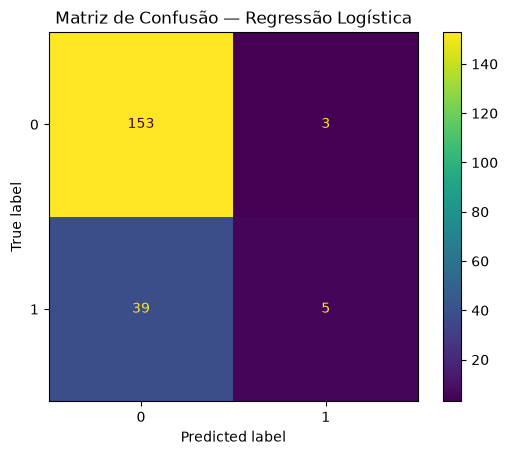

In [98]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred,
)

plt.title("Matriz de Confusão — Regressão Logística")
plt.show()

In [99]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_teste,
        y_pred,
        target_names=[
            "Não precisa revisão",
            "Precisa revisão",
        ],
    )
)

                     precision    recall  f1-score   support

Não precisa revisão       0.80      0.98      0.88       156
    Precisa revisão       0.62      0.11      0.19        44

           accuracy                           0.79       200
          macro avg       0.71      0.55      0.54       200
       weighted avg       0.76      0.79      0.73       200



## Regressão Logística com balanceamento de classes

O modelo inicial apresentou bom desempenho na identificação de produtos
que não precisam de revisão, porém baixo recall para produtos que realmente
necessitam de revisão.

Como falsos negativos possuem maior impacto no contexto do projeto,
será testada uma versão da Regressão Logística com balanceamento de classes.

In [100]:
modelo_balanceado = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "classificador",
            LogisticRegression(
                random_state=RANDOM_STATE,
                max_iter=1000,
                class_weight="balanced",
            ),
        ),
    ]
)

In [101]:
modelo_balanceado.fit(
    X_treino,
    y_treino,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['categoria','preco','quantidade',...,'dias_para_vencer', 'temperatura_armazenamento','historico_problemas']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...), ('numericas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

In [102]:
print("MODELO ORIGINAL")
print(
    classification_report(
        y_teste,
        y_pred,
        target_names=[
            "Não precisa revisão",
            "Precisa revisão",
        ],
    )
)

print("\nMODELO BALANCEADO")
print(
    classification_report(
        y_teste,
        y_pred_balanceado,
        target_names=[
            "Não precisa revisão",
            "Precisa revisão",
        ],
    )
)

MODELO ORIGINAL
                     precision    recall  f1-score   support

Não precisa revisão       0.80      0.98      0.88       156
    Precisa revisão       0.62      0.11      0.19        44

           accuracy                           0.79       200
          macro avg       0.71      0.55      0.54       200
       weighted avg       0.76      0.79      0.73       200


MODELO BALANCEADO
                     precision    recall  f1-score   support

Não precisa revisão       0.85      0.68      0.75       156
    Precisa revisão       0.33      0.57      0.42        44

           accuracy                           0.66       200
          macro avg       0.59      0.62      0.59       200
       weighted avg       0.73      0.66      0.68       200



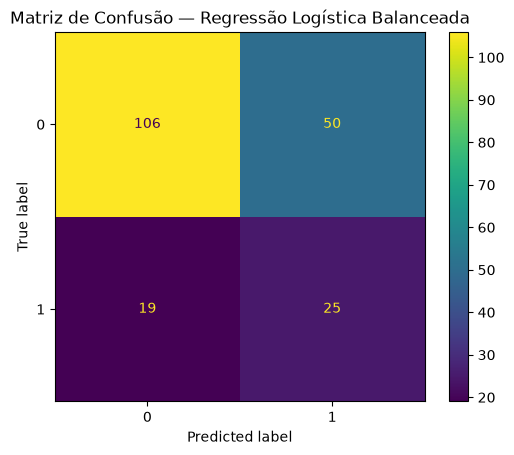

In [103]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_balanceado,
)

plt.title(
    "Matriz de Confusão — Regressão Logística Balanceada"
)

plt.show()

## Comparação com Random Forest

Após identificar baixo recall no modelo inicial e aplicar balanceamento
de classes à Regressão Logística, será avaliado um segundo algoritmo.

O Random Forest será utilizado para verificar se relações não lineares
entre as características dos produtos podem melhorar a identificação
dos itens que necessitam de revisão.

In [104]:
from sklearn.ensemble import RandomForestClassifier


modelo_random_forest = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "classificador",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)

In [105]:
modelo_random_forest.fit(
    X_treino,
    y_treino,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['categoria','preco','quantidade',...,'dias_para_vencer', 'temperatura_armazenamento','historico_problemas']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoricas', ...), ('numericas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default o

In [106]:
y_pred_rf = modelo_random_forest.predict(X_teste)

In [107]:
print(
    classification_report(
        y_teste,
        y_pred_rf,
        target_names=[
            "Não precisa revisão",
            "Precisa revisão",
        ],
    )
)

                     precision    recall  f1-score   support

Não precisa revisão       0.82      0.83      0.82       156
    Precisa revisão       0.36      0.34      0.35        44

           accuracy                           0.72       200
          macro avg       0.59      0.58      0.59       200
       weighted avg       0.72      0.72      0.72       200



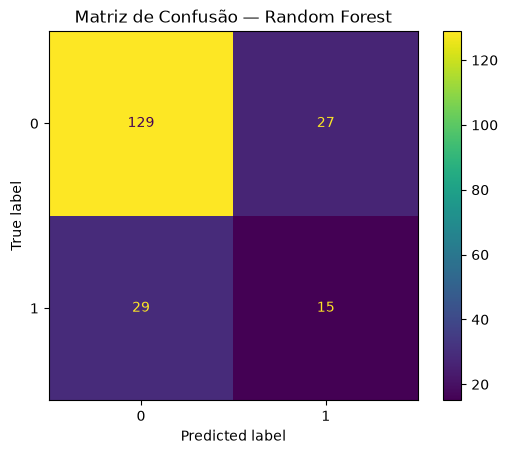

In [108]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred_rf,
)

plt.title("Matriz de Confusão — Random Forest")
plt.show()

## Análise dos limiares de decisão

As probabilidades do modelo balanceado serão comparadas com limiares de `0.30`
a `0.70`, observando precisão e recall. A comparação usa o mesmo conjunto de
teste e é exploratória. Escolher modelos ou limiares a partir desses resultados
exige avaliação posterior em dados separados para estimar o desempenho final.


In [109]:
probabilidades = modelo_balanceado.predict_proba(X_teste)

probabilidades[:5]

array([[0.79241009, 0.20758991],
       [0.70032902, 0.29967098],
       [0.28122282, 0.71877718],
       [0.71573074, 0.28426926],
       [0.62132532, 0.37867468]])

In [110]:
probabilidade_revisao = modelo_balanceado.predict_proba(
    X_teste
)[:, 1]

probabilidade_revisao[:10]

array([0.20758991, 0.29967098, 0.71877718, 0.28426926, 0.37867468,
       0.18767148, 0.24948509, 0.76192458, 0.42875734, 0.61235158])

In [111]:
thresholds = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
]

resultados = []

for threshold in thresholds:
    previsoes = (
        probabilidade_revisao >= threshold
    ).astype(int)

    resultados.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_teste,
            previsoes,
        ),
        "precision": precision_score(
            y_teste,
            previsoes,
            zero_division=0,
        ),
        "recall": recall_score(
            y_teste,
            previsoes,
            zero_division=0,
        ),
        "f1": f1_score(
            y_teste,
            previsoes,
            zero_division=0,
        ),
    })

df_thresholds = pd.DataFrame(resultados)

df_thresholds

,threshold,accuracy,precision,recall,f1
0,0.3,0.505,0.286822,0.840909,0.427746
1,0.4,0.610,0.336538,0.795455,0.472973
2,0.5,0.655,0.333333,0.568182,0.420168
3,0.6,0.720,0.392857,0.500000,0.440000
4,0.7,0.765,0.440000,0.250000,0.318841


## Exportação e integração

O pipeline balanceado será exportado para `ml/models/quality_model.joblib`,
incluindo pré-processamento e classificador. O artefato é ignorado pelo Git e
pode ser recriado executando o notebook.

`ml/models/model_config.json` registra o alvo `precisa_revisao`, a classe positiva
`1` e o limiar `0.4`. Esse limiar é externo: `predict()` mantém a decisão padrão
do classificador. Para aplicar `0.4`, a integração deverá comparar a
probabilidade da classe positiva com esse valor.

O backend atual usa regras próprias e ainda não carrega o modelo. Uma integração
futura deverá mapear os campos abaixo; os demais campos mantêm seus nomes.

| Campo da API | Coluna do modelo |
| --- | --- |
| `dias_para_expiracao` | `dias_para_vencer` |
| `temperatura_de_armazenamento` | `temperatura_armazenamento` |
| `historico_de_problemas` | `historico_problemas` |


In [112]:
import joblib
from pathlib import Path

# Localiza o projeto a partir da pasta de execução do Jupyter.
PASTA_ATUAL = Path.cwd().resolve()
RAIZ_PROJETO = next(
    (
        pasta
        for pasta in (PASTA_ATUAL, *PASTA_ATUAL.parents)
        if (pasta / "ml/notebooks/01_exploracao_dados.ipynb").is_file()
    ),
    None,
)
if RAIZ_PROJETO is None:
    raise FileNotFoundError(
        "Execute o notebook na raiz do ai-quality-inspector ou em uma subpasta."
    )

MODEL_PATH = RAIZ_PROJETO / "ml" / "models"

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True,
)

joblib.dump(
    modelo_balanceado,
    MODEL_PATH / "quality_model.joblib",
)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


### Threshold selecionado

Foi adotado o threshold de **0,40** para a classificação de produtos que
necessitam de revisão.

Essa escolha prioriza o recall da classe positiva, pois falsos negativos
representam produtos que deveriam passar por revisão, mas seriam liberados
pelo sistema.

No conjunto de teste, o threshold de 0,40 apresentou recall de aproximadamente
79,5% e o maior F1-score entre os thresholds avaliados.

O valor é uma decisão experimental deste projeto e deverá ser reavaliado
caso o modelo seja aplicado a dados reais.